In [1]:
import pandas as pd
import numpy as np
import scipy
import scipy.sparse as sp
import scipy.io as sio
import scipy.stats as stats
from tqdm.notebook import tqdm
from matplotlib.ticker import FormatStrFormatter


import os
os.environ["R_HOME"] = f"{os.environ['CONDA_PREFIX']}\\Lib\\R"


from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from plotnine import *
from mizani.formatters import label_number
fmt2 = label_number(accuracy=0.01)  # 2 decimal places

import matplotlib.pyplot as plt 


from scipy.sparse import coo_matrix
from scipy.sparse import csr_matrix
import pickle

from joblib import Parallel, delayed
from pathlib import Path
import sys

# Get project root as parent of notebooks/
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.methods.GWASH_funcs import *
from src.methods.GWASH_sim_funcs import *
from src.methods.ldsc_barebones import *

from src.simtools.sim_utils import *
from src.simtools.data_generation import data_generation as data_generation
from src.simtools.data_preprocessing import data_preprocessing as data_preprocessing
from src.simtools.do_analysis import do_analysis as do_analysis
from src.simtools.run_simulations import run_simulations as run_simulations
from src.simtools.data_generation import gen_ref_ldscores_panel as gen_ref_ldscores_panel
from src.simtools.visualization import visualize
import matplotlib.ticker as mticker
from natsort import natsorted

import pickle

os.chdir(PROJECT_ROOT)

# Figure A1

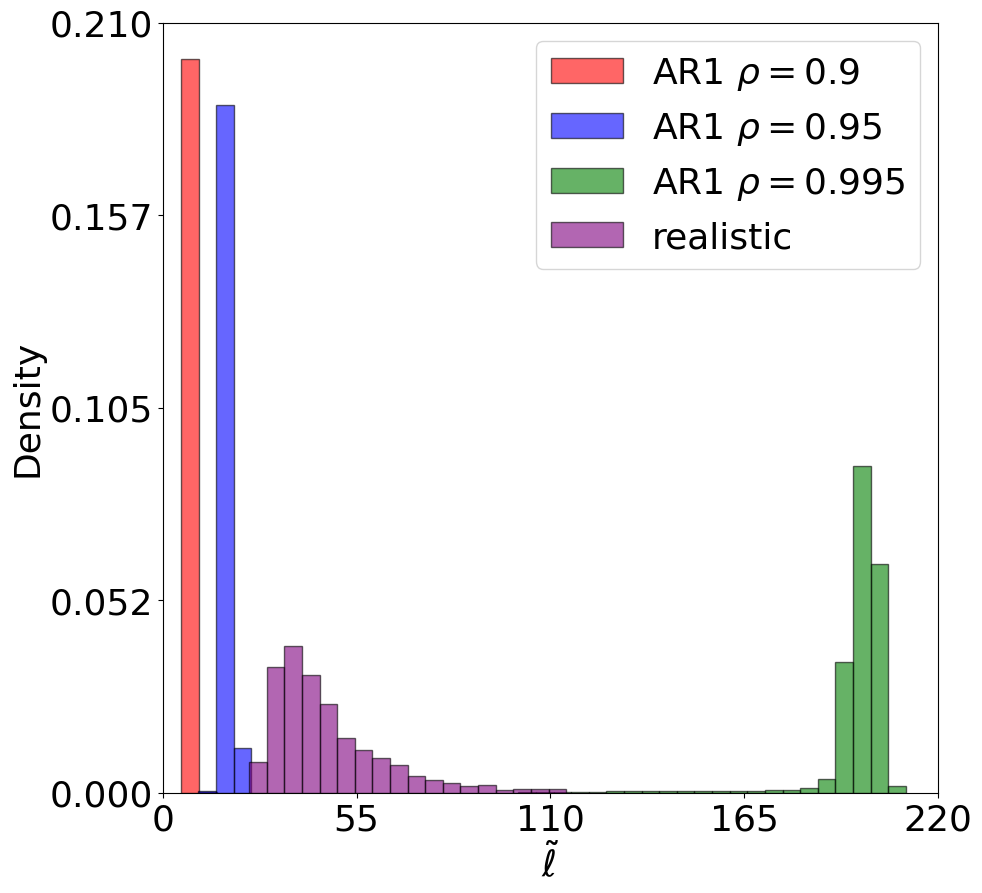

In [24]:
def get_bins_from_width(data,desired_bin_width):
    bins = np.arange(data.min(), data.max() + desired_bin_width, desired_bin_width)
    return bins

def plot_ldscores_u2s_histograms(Fst,sigma_s,mode = 'ldscores',bin_width = 5):
    plt.clf()
    plt.rcParams.update({'font.size': 26})
    plt.rcParams['figure.figsize'] = (10, 10)
    plt.gca().yaxis.set_major_locator(mticker.LinearLocator(5))
    plt.gca().xaxis.set_major_locator(mticker.LinearLocator(5))
    
    rho = 0.9

    if mode == 'ldscores':
        AR1_key = 'AR1_ldscores'
        realistic_key = 'ldscores'
        xlab  = r'$\tilde{\ell}$'
        plot_title = r'Histogram of LD Scores | $\mathrm{F_{st}} = $' +  '{Fst}'.format(Fst = str(Fst)) + r', $\sigma_{s}$ = ' + '{sigma_s}'.format(sigma_s = str(sigma_s))
        plot_xlim = 220
    else:
        AR1_key = 'u2s'
        realistic_key = 'u2s'
        xlab  = r'$\chi^{2}$'
        plot_title = r'Histogram of $\chi^{2}$s | $\mathrm{F_{st}} = $' +   '{Fst}'.format(Fst = str(Fst)) + r', $\sigma_{s}$ = ' + '{sigma_s}'.format(sigma_s = str(sigma_s))
        plot_xlim = 300
        
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/AR1/AR1_rho{rho}_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    a = res_dict_raw[AR1_key].flatten()

    #plt.figure(figsize=(10, 6))
    plt.hist(a, bins=get_bins_from_width(a,bin_width), color='red', edgecolor='black', alpha=0.6, label=r'AR1 $\rho = 0.9$',density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim)) 
    
    
    rho = 0.95
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/AR1/AR1_rho{rho}_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    b = res_dict_raw[AR1_key].flatten()

    #plt.figure(figsize=(10, 6))
    plt.hist(b, bins=get_bins_from_width(b,bin_width), color='blue', edgecolor='black', alpha=0.6, label=r'AR1 $\rho = $'+'{rho}'.format(rho = str(rho)),density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim)) 
    rho = 0.995
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/AR1/AR1_rho{rho}_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    c = res_dict_raw[AR1_key].flatten()

    #plt.figure(figsize=(10, 6))
    plt.hist(c, bins=get_bins_from_width(c,bin_width), color='green', edgecolor='black', alpha=0.6, label=r'AR1 $\rho = $'+'{rho}'.format(rho = str(rho)),density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim)) 
    
    
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/realistic/realistic_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    
    d = res_dict_raw[realistic_key].flatten()
    
    plt.hist(d, bins=get_bins_from_width(d,bin_width), color='purple', edgecolor='black', alpha=0.6, label=r'realistic',density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim))
    
    plt.xlabel(xlab)
    #plt.title(plot_title)
    plt.ylabel('Density')
    plt.legend(loc='upper right')

    return plt

Fsts = [0]
sigma_ss = [0]
for Fst in Fsts:
    for sigma_s in sigma_ss:
        q1 = plot_ldscores_u2s_histograms(Fst,sigma_s,'u2s',bin_width = 10).savefig('figures/appendix/Figure_A1/u2_histogram_Fst{Fst}_sigma_s{sigma_s}.png'.format(Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')),dpi = 600, bbox_inches='tight')
        q2 = plot_ldscores_u2s_histograms(Fst,sigma_s,'ldscores',bin_width = 5).savefig('figures/appendix/Figure_A1/ldscore_histogram_Fst{Fst}_sigma_s{sigma_s}.png'.format(Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')),dpi = 600, bbox_inches='tight')

# Figure A2

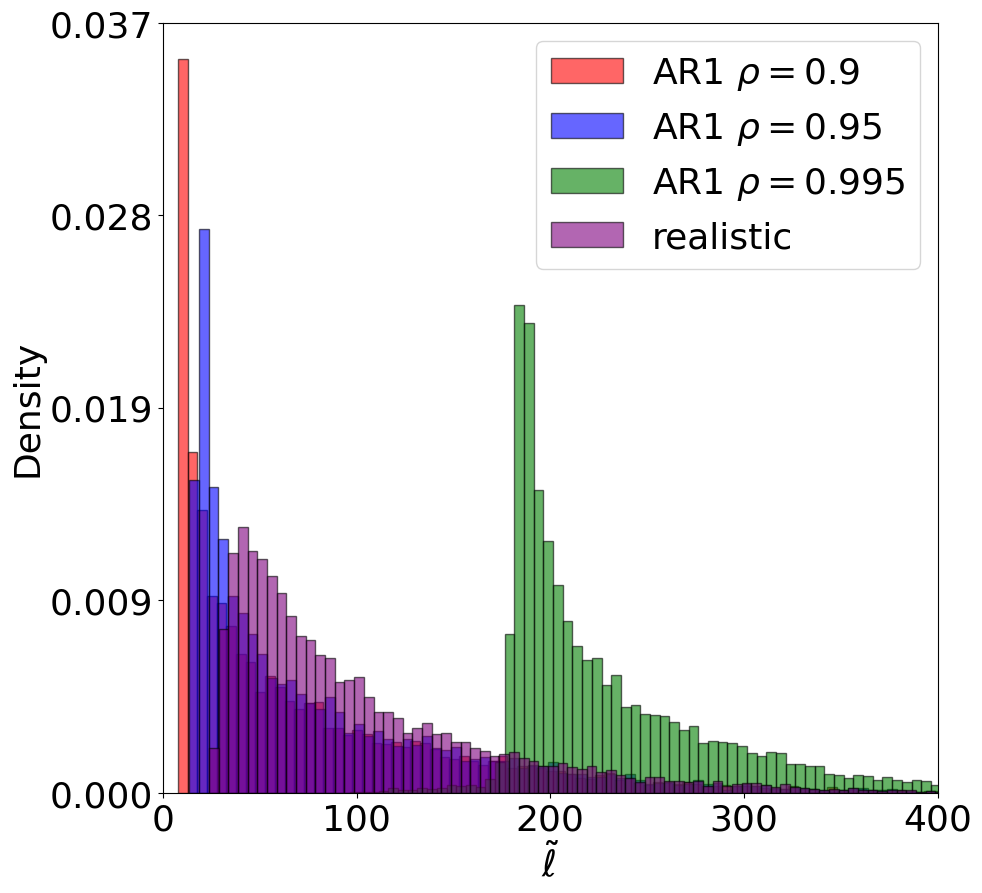

In [17]:
def get_bins_from_width(data,desired_bin_width):
    bins = np.arange(data.min(), data.max() + desired_bin_width, desired_bin_width)
    return bins

def plot_ldscores_u2s_histograms(Fst,sigma_s,mode = 'ldscores',bin_width = 5):
    plt.clf()
    plt.gca().yaxis.set_major_locator(mticker.LinearLocator(5))
    plt.gca().xaxis.set_major_locator(mticker.LinearLocator(5))
    plt.rcParams.update({'font.size': 26})
    plt.rcParams['figure.figsize'] = (10, 10)
    rho = 0.9

    if mode == 'ldscores':
        AR1_key = 'AR1_ldscores'
        realistic_key = 'ldscores'
        xlab  = r'$\tilde{\ell}$'
        plot_title = r'Histogram of LD Scores | $\mathrm{F_{st}} = $' +  '{Fst}'.format(Fst = str(Fst)) + r', $\sigma_{s}$ = ' + '{sigma_s}'.format(sigma_s = str(sigma_s))
        plot_xlim = 400
    else:
        AR1_key = 'u2s'
        realistic_key = 'u2s'
        xlab  = r'$\chi^{2}$'
        plot_title = r'Histogram of $\chi^{2}$s | $\mathrm{F_{st}} = $' +   '{Fst}'.format(Fst = str(Fst)) + r', $\sigma_{s}$ = ' + '{sigma_s}'.format(sigma_s = str(sigma_s))
        plot_xlim = 300
        
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/AR1/AR1_rho{rho}_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    a = res_dict_raw[AR1_key].flatten()

    #plt.figure(figsize=(10, 6))
    plt.hist(a, bins=get_bins_from_width(a,bin_width), color='red', edgecolor='black', alpha=0.6, label=r'AR1 $\rho = 0.9$',density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim)) 
    
    
    rho = 0.95
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/AR1/AR1_rho{rho}_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    b = res_dict_raw[AR1_key].flatten()

    #plt.figure(figsize=(10, 6))
    plt.hist(b, bins=get_bins_from_width(b,bin_width), color='blue', edgecolor='black', alpha=0.6, label=r'AR1 $\rho = $'+'{rho}'.format(rho = str(rho)),density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim)) 
    rho = 0.995
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/AR1/AR1_rho{rho}_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    c = res_dict_raw[AR1_key].flatten()

    #plt.figure(figsize=(10, 6))
    plt.hist(c, bins=get_bins_from_width(c,bin_width), color='green', edgecolor='black', alpha=0.6, label=r'AR1 $\rho = $'+'{rho}'.format(rho = str(rho)),density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim)) 
    
    
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/realistic/realistic_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    
    d = res_dict_raw[realistic_key].flatten()
    
    plt.hist(d, bins=get_bins_from_width(d,bin_width), color='purple', edgecolor='black', alpha=0.6, label=r'realistic',density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim))
    
    plt.xlabel(xlab)
    #plt.title(plot_title)
    plt.ylabel('Density')
    plt.legend(loc='upper right')

    return plt

Fsts = [0.05,0.1]
sigma_ss = [0]
for Fst in Fsts:
    for sigma_s in sigma_ss:
        q1 = plot_ldscores_u2s_histograms(Fst,sigma_s,'u2s',bin_width = 10).savefig('figures/appendix/Figure_A2/u2_histogram_Fst{Fst}_sigma_s{sigma_s}.png'.format(Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')),dpi = 600, bbox_inches='tight')
        q2 = plot_ldscores_u2s_histograms(Fst,sigma_s,'ldscores',bin_width = 5).savefig('figures/appendix/Figure_A2/ldscore_histogram_Fst{Fst}_sigma_s{sigma_s}.png'.format(Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')),dpi = 600, bbox_inches='tight')

# Figure A3

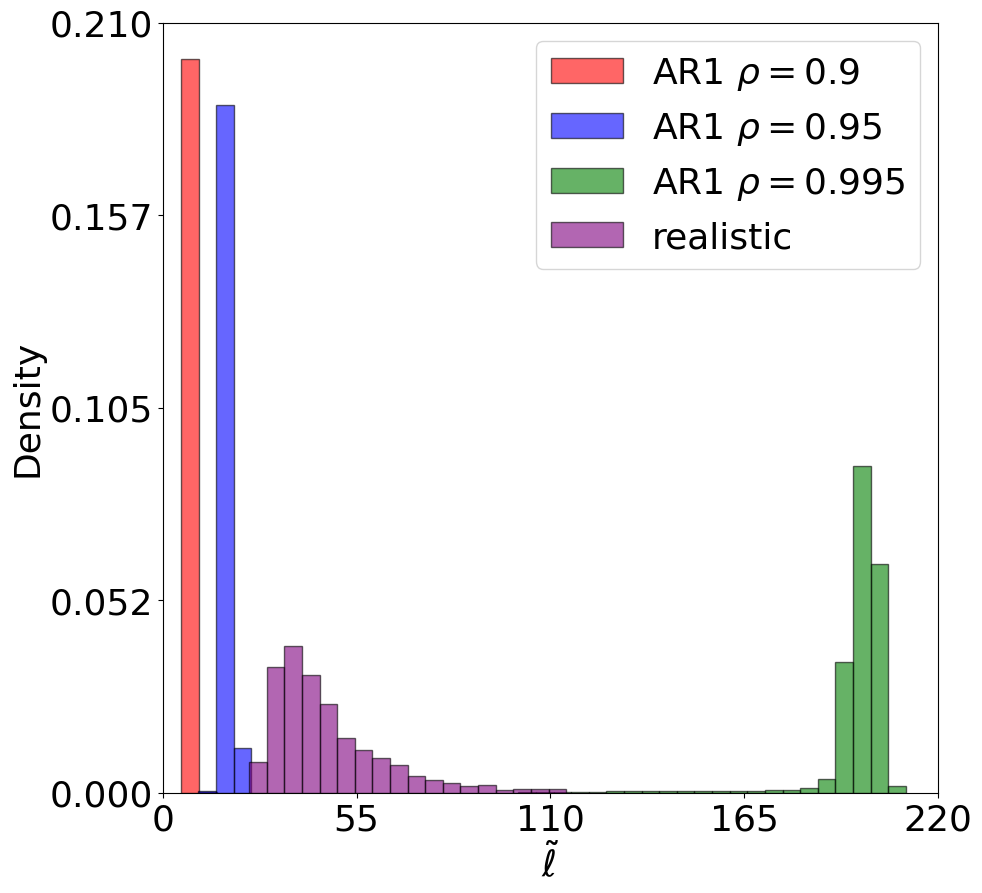

In [18]:
def get_bins_from_width(data,desired_bin_width):
    bins = np.arange(data.min(), data.max() + desired_bin_width, desired_bin_width)
    return bins

def plot_ldscores_u2s_histograms(Fst,sigma_s,mode = 'ldscores',bin_width = 5):
    plt.clf()
    plt.rcParams.update({'font.size': 26})
    plt.rcParams['figure.figsize'] = (10, 10)
    plt.gca().yaxis.set_major_locator(mticker.LinearLocator(5))
    plt.gca().xaxis.set_major_locator(mticker.LinearLocator(5))
    rho = 0.9

    if mode == 'ldscores':
        AR1_key = 'AR1_ldscores'
        realistic_key = 'ldscores'
        xlab  = r'$\tilde{\ell}$'
        plot_title = r'Histogram of LD Scores | $\mathrm{F_{st}} = $' +  '{Fst}'.format(Fst = str(Fst)) + r', $\sigma_{s}$ = ' + '{sigma_s}'.format(sigma_s = str(sigma_s))
        plot_xlim = 220
    else:
        AR1_key = 'u2s'
        realistic_key = 'u2s'
        xlab  = r'$\chi^{2}$'
        plot_title = r'Histogram of $\chi^{2}$s | $\mathrm{F_{st}} = $' +   '{Fst}'.format(Fst = str(Fst)) + r', $\sigma_{s}$ = ' + '{sigma_s}'.format(sigma_s = str(sigma_s))
        plot_xlim = 300
        
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/AR1/AR1_rho{rho}_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    a = res_dict_raw[AR1_key].flatten()

    #plt.figure(figsize=(10, 6))
    plt.hist(a, bins=get_bins_from_width(a,bin_width), color='red', edgecolor='black', alpha=0.6, label=r'AR1 $\rho = 0.9$',density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim)) 
    
    
    rho = 0.95
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/AR1/AR1_rho{rho}_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    b = res_dict_raw[AR1_key].flatten()

    #plt.figure(figsize=(10, 6))
    plt.hist(b, bins=get_bins_from_width(b,bin_width), color='blue', edgecolor='black', alpha=0.6, label=r'AR1 $\rho = $'+'{rho}'.format(rho = str(rho)),density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim)) 
    rho = 0.995
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/AR1/AR1_rho{rho}_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    c = res_dict_raw[AR1_key].flatten()

    #plt.figure(figsize=(10, 6))
    plt.hist(c, bins=get_bins_from_width(c,bin_width), color='green', edgecolor='black', alpha=0.6, label=r'AR1 $\rho = $'+'{rho}'.format(rho = str(rho)),density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim)) 
    
    
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/realistic/realistic_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    
    d = res_dict_raw[realistic_key].flatten()
    
    plt.hist(d, bins=get_bins_from_width(d,bin_width), color='purple', edgecolor='black', alpha=0.6, label=r'realistic',density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim))
    
    plt.xlabel(xlab)
    #plt.title(plot_title)
    plt.ylabel('Density')
    plt.legend(loc='upper right')

    return plt

Fsts = [0]
sigma_ss = [0.4,0.8]
for Fst in Fsts:
    for sigma_s in sigma_ss:
        q1 = plot_ldscores_u2s_histograms(Fst,sigma_s,'u2s',bin_width = 10).savefig('figures/appendix/Figure_A3/u2_histogram_Fst{Fst}_sigma_s{sigma_s}.png'.format(Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')),dpi = 600, bbox_inches='tight')
        q2 = plot_ldscores_u2s_histograms(Fst,sigma_s,'ldscores',bin_width = 5).savefig('figures/appendix/Figure_A3/ldscore_histogram_Fst{Fst}_sigma_s{sigma_s}.png'.format(Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')),dpi = 600, bbox_inches='tight')

# Figure A4

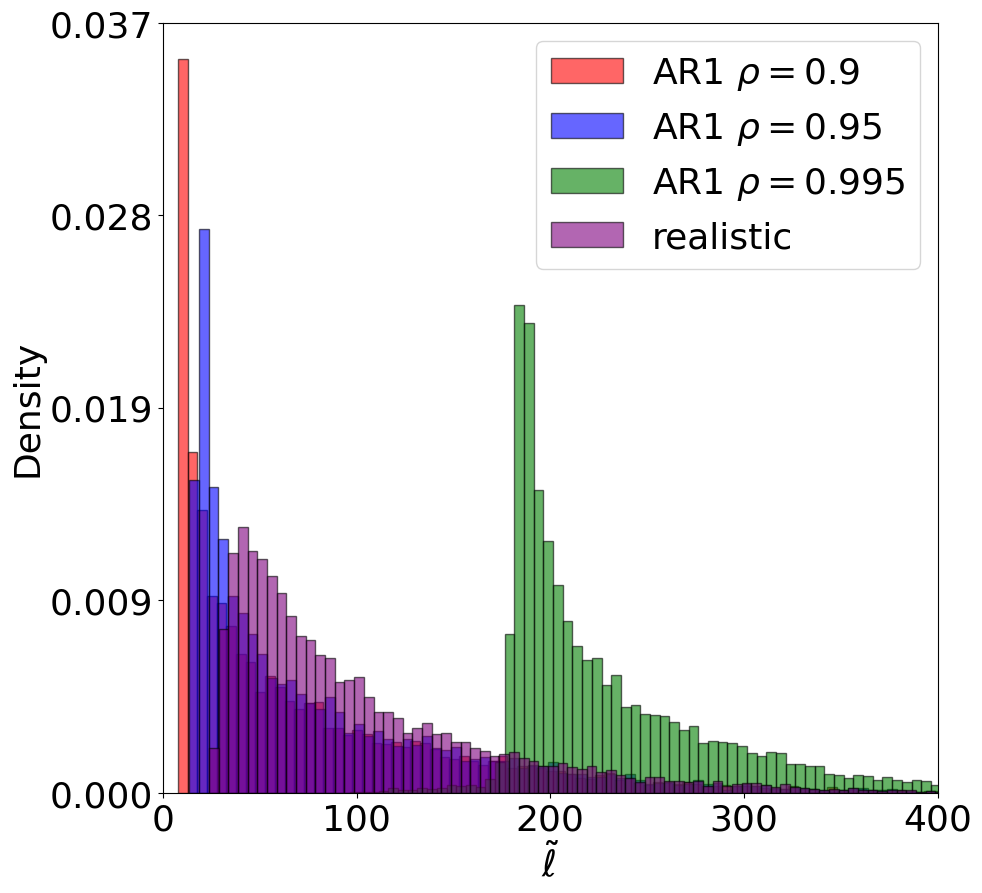

In [19]:
def get_bins_from_width(data,desired_bin_width):
    bins = np.arange(data.min(), data.max() + desired_bin_width, desired_bin_width)
    return bins

def plot_ldscores_u2s_histograms(Fst,sigma_s,mode = 'ldscores',bin_width = 5):
    plt.clf()
    plt.rcParams.update({'font.size': 26})
    plt.rcParams['figure.figsize'] = (10, 10)
    plt.gca().yaxis.set_major_locator(mticker.LinearLocator(5))
    plt.gca().xaxis.set_major_locator(mticker.LinearLocator(5))
    rho = 0.9

    if mode == 'ldscores':
        AR1_key = 'AR1_ldscores'
        realistic_key = 'ldscores'
        xlab  = r'$\tilde{\ell}$'
        plot_title = r'Histogram of LD Scores | $\mathrm{F_{st}} = $' +  '{Fst}'.format(Fst = str(Fst)) + r', $\sigma_{s}$ = ' + '{sigma_s}'.format(sigma_s = str(sigma_s))
        plot_xlim = 400
    else:
        AR1_key = 'u2s'
        realistic_key = 'u2s'
        xlab  = r'$\chi^{2}$'
        plot_title = r'Histogram of $\chi^{2}$s | $\mathrm{F_{st}} = $' +   '{Fst}'.format(Fst = str(Fst)) + r', $\sigma_{s}$ = ' + '{sigma_s}'.format(sigma_s = str(sigma_s))
        plot_xlim = 1200
        
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/AR1/AR1_rho{rho}_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    a = res_dict_raw[AR1_key].flatten()

    #plt.figure(figsize=(10, 6))
    plt.hist(a, bins=get_bins_from_width(a,bin_width), color='red', edgecolor='black', alpha=0.6, label=r'AR1 $\rho = 0.9$',density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim)) 
    
    
    rho = 0.95
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/AR1/AR1_rho{rho}_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    b = res_dict_raw[AR1_key].flatten()

    #plt.figure(figsize=(10, 6))
    plt.hist(b, bins=get_bins_from_width(b,bin_width), color='blue', edgecolor='black', alpha=0.6, label=r'AR1 $\rho = $'+'{rho}'.format(rho = str(rho)),density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim)) 
    rho = 0.995
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/AR1/AR1_rho{rho}_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    c = res_dict_raw[AR1_key].flatten()

    #plt.figure(figsize=(10, 6))
    plt.hist(c, bins=get_bins_from_width(c,bin_width), color='green', edgecolor='black', alpha=0.6, label=r'AR1 $\rho = $'+'{rho}'.format(rho = str(rho)),density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim)) 
    
    
    res_dict_raw = pickle.load(open("save_data/appendix/ldscores_chi2_100sim_data/realistic/realistic_Fst{Fst}_sigma_s{sigma_s}_ldscores_u2s_100sims_refpanel_seed123.pkl".format(rho = str(rho).replace('.',''),Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')), "rb"))
    
    d = res_dict_raw[realistic_key].flatten()
    
    plt.hist(d, bins=get_bins_from_width(d,bin_width), color='purple', edgecolor='black', alpha=0.6, label=r'realistic',density = True)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    plt.xlim((0, plot_xlim))
    
    plt.xlabel(xlab)
    #plt.title(plot_title)
    plt.ylabel('Density')
    plt.legend(loc='upper right')

    return plt

Fsts = [0.05,0.1]
sigma_ss = [0.4,0.8]
for Fst in Fsts:
    for sigma_s in sigma_ss:
        q1 = plot_ldscores_u2s_histograms(Fst,sigma_s,'u2s',bin_width = 10).savefig('figures/appendix/Figure_A4/u2_histogram_Fst{Fst}_sigma_s{sigma_s}.png'.format(Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')),dpi = 600, bbox_inches='tight')
        q2 = plot_ldscores_u2s_histograms(Fst,sigma_s,'ldscores',bin_width = 5).savefig('figures/appendix/Figure_A4/ldscore_histogram_Fst{Fst}_sigma_s{sigma_s}.png'.format(Fst = str(Fst).replace('.',''), sigma_s = str(sigma_s).replace('.','')),dpi = 600, bbox_inches='tight')

# Figure A5

In [ ]:
res_pm_0 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_0.txt')
res_pm_5 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_5.txt')
res_pm_10 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_10.txt')
res_pm_15 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_15.txt')
res_pm_20 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_20.txt')
res_pm_25 = pd.read_table('save_data/experiment/realistic_Fst0_100sims_ref_panel_pm_25.txt')

res_dict_raw = dict()
res_dict_raw[r'0'] = res_pm_0
res_dict_raw[r'5'] = res_pm_5
res_dict_raw[r'10'] = res_pm_10
res_dict_raw[r'15'] = res_pm_15
res_dict_raw[r'20'] = res_pm_20
res_dict_raw[r'25'] = res_pm_25
param = r'$C$'
axis_labels = ylab(r'$h^{2}_{est}$') + xlab(param)
title = ggtitle('h2_pop = 0.2 \n {param}, 100 Simulations'.format(param = param))

p = visualize(res_dict_raw,_,xparam=param,h2_pop = 0.2, plot_h2_samp = False,h2_reasonable_ylim = True,publication = True,CI_mode = 'quantile',sd_constant = 2).plot_lineplot() + ylab(r'$h^{2}_{est}$')


ggsave(p,'figures/appendix/Figure_A5/realistic_Fst0_100sims_ref_panel_pm_C_all.png',dpi = 600)

p

# Figure A6

In [ ]:
res_dict_raw = pickle.load(open('save_data/appendix/realistic/h2_pop.pkl','rb'))
param = r'$h^{2}_{g}$'
p = visualize(res_dict_raw,_,xparam=param,h2_pop = 0.2, plot_h2_samp = False,h2_reasonable_ylim = True,publication = True,CI_mode = 'quantile',sd_constant = 2).plot_lineplot() + geom_hline(yintercept=0.01,color = 'red',linetype ='--') + geom_hline(yintercept=0.4,color = 'red',linetype ='--') + geom_hline(yintercept=0.6,color = 'red',linetype ='--') + geom_hline(yintercept=0.8,color = 'red',linetype ='--') + ylab(r'$h^{2}_{est}$')

ggsave(p,'figures/appendix/Figure_A6/realistic_h2pop.png',dpi = 600)